# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [40]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
plans = pd.read_csv('/datasets/plans.csv') # cargar archivos
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [42]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [43]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [44]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.

In [45]:
# revisar el número de filas y columnas de cada dataset
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [46]:
# inspección de plans con .info()
print("\n--- plans ---")
plans.info()


--- plans ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [47]:
# inspección de users con .info()
print("\n--- users ---")
users.info()


--- users ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [48]:
# inspección de usage con .info()
print("\n--- usage ---")
usage.info()


--- usage ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [49]:
# cantidad de nulos para users
print("Nulos en users:")
print(users.isna().sum())

print("\nProporción de nulos en users:")
print(users.isna().mean())

Nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de nulos en users:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [50]:
# cantidad de nulos para usage

**Valores nulos**  

Dataset `users`
    • city (11.7% nulos) → Magnitud moderada. Recomendación: investigar si se puede imputar con información externa (ej. ciudad más frecuente por plan) o dejar como NA para no sesgar.
    • churn_date (88.3% nulos) → Magnitud muy alta. Recomendación: no imputar; mantener como NA ya que refleja clientes activos (solo unos pocos tienen fecha de baja).
  
  Dataset `usage`
• date (0.1% nulos) → Magnitud muy baja. Recomendación: imputar con fecha aproximada si es posible o simplemente dejar como NA, no afecta el análisis global.
• duration (55.2% nulos) → Magnitud muy alta. Recomendación: mantener como NA, ya que aplica sólo a mensajes (no tienen duración). No imputar porque es estructural.
• length (44.7% nulos) → Magnitud alta. Recomendación: mantener como NA, ya que aplica sólo a llamadas (no tienen longitud). No imputar porque es estructural.

Conclusión ejecutiva
• plans: no requiere tratamiento, no tiene nulos.
• users: city puede imputarse o dejarse como NA; churn_date se conserva como NA porque es informativo.
• usage: date se puede imputar o ignorar; duration y length deben mantenerse como NA porque dependen del tipo de uso (llamada vs mensaje).

👉 En resumen: los nulos en users y usage no son errores críticos, sino parte de la estructura de los datos. Se deben manejar con reglas claras de imputación o conservación según el contexto.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [51]:
# explorar columnas numéricas de users
print("Resumen numérico de users:")
print(users.describe())

Resumen numérico de users:
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


Insights clave del dataset `users`
• Sentinel detectado (-999): Este valor no corresponde a una edad real y distorsiona las estadísticas. Debe reemplazarse por NaN para mantener la calidad del análisis.
• Distribución central: La mayoría de los clientes se concentran entre 32 y 63 años, con una mediana de 47 años, lo que refleja un perfil de usuario adulto en edad laboral.
• Rango máximo válido: El cliente más longevo tiene 79 años, dentro de un rango plausible.
• Desviación estándar inflada (123): Este valor es artificialmente alto debido al sentinel; una vez corregido, la dispersión será mucho más representativa.
• Identificadores (user_id): Van de 10000 a 13999, consecutivos y sin problemas de calidad.

Recomendaciones
• Reemplazar -999 por NaN en age.
• Mantener la distribución natural de edades para segmentaciones futuras (ej. jóvenes vs adultos mayores).
• Usar la mediana (47 años) como referencia para imputación si se requiere, ya que es robusta frente a outliers.
👉 En conclusión: la base de clientes está mayoritariamente en edad laboral, con un sentinel claro que debe corregirse para evitar sesgos en el análisis.

In [52]:
# explorar columnas numéricas de usage
print("\nResumen numérico de usage:")
print(usage.describe())


Resumen numérico de usage:
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


Insights clave del dataset `usage`
• Estructura confiable:


Insights clave del dataset `usage`
• Estructura confiable:
	◦ id y user_id están completos, sin nulos, y permiten vincular cada transacción con un cliente.
• Duración de llamadas (duration):
	◦ Mediana de 3.5 minutos, lo que refleja un uso típico moderado.
	◦ Máximo de 120 minutos → posible outlier o caso especial (llamadas muy largas).
	◦ Valores mínimos en 0 → llamadas registradas sin duración, probablemente errores o intentos fallidos.
• Longitud de mensajes (length):
	◦ Mediana de 50 caracteres, lo que corresponde a mensajes cortos y directos.
	◦ Máximo de 1490 caracteres → mensajes inusualmente largos, potencial outlier.
	◦ Valores mínimos en 0 → mensajes vacíos o registros defectuosos.
• Distribución general:
	◦ La mayoría de los clientes usan llamadas cortas y mensajes breves.
	◦ Existen outliers tanto en llamadas como en mensajes que deben revisarse para descartar fraude o errores de registro.

Recomendaciones
• Mantener id y user_id como llaves de integración.
• Tratar valores 0 en duración y longitud como posibles registros defectuosos → marcarlos como NA.
• Revisar outliers extremos (llamadas >60 min, mensajes >500 caracteres) para validar si son reales o errores.
• Usar la mediana como referencia de comportamiento típico, ya que es robusta frente a valores atípicos.
👉 En conclusión: el dataset usage es sólido para análisis, pero requiere limpieza de registros con duración/longitud igual a 0 y revisión de outliers para asegurar calidad.

In [53]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

print("\nValores únicos en users['city']:")
print(users['city'].unique()[:20])  # muestra primeros 20 para no saturar

#print("\nValores únicos en users['plan']:")
print(users['plan'].unique())



Valores únicos en users['city']:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']


Insights columnas categóricas dataset 'user':

• City:
	◦ Valores válidos: Medellín, CDMX, Bogotá, GDL, MTY, Cali.
	◦ Problemas: '?' y NaN son sentinels que no representan ciudades reales.
	◦ Acción recomendada: reemplazar '?' por NaN y decidir si imputar (ej. ciudad más frecuente) o dejar como ausente.

• Plan:
	◦ Valores: Basico y Premium.
	◦ Limpio y consistente con el catálogo de planes.
	◦ Acción recomendada: mantener sin cambios, listo para segmentación.

---
En conclusión: el único problema relevante está en la columna city, que contiene valores inválidos ('?' y ausentes). Las columnas plan y type están limpias y listas para análisis. Esto significa que la limpieza debe enfocarse en city, mientras que las demás variables categóricas pueden usarse directamente para segmentación y análisis de comportamiento.

In [54]:
# explorar columna categórica de usage
usage['type'] 
print("\nValores únicos en usage['type']:")
print(usage['type'].unique()) # completa el código


Valores únicos en usage['type']:
['call' 'text']


Insights columnas categóricas dataset 'usage':

• Type:
	◦ Valores: call y text.
	◦ Correctos y sin sentinels.
	◦ Acción recomendada: mantener sin cambios, clave para diferenciar patrones de uso.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Diagnóstico de valores inválidos / sentinels
• users['city']
	◦ Valores inválidos: '?' y NaN.
	◦ Acción recomendada: reemplazar '?' por NaN y luego decidir si imputar (ej. ciudad más frecuente por país/plan) o dejar como ausente para no sesgar.
• users['plan']
	◦ Valores válidos: solo 'Basico' y 'Premium'.
	◦ Acción recomendada: mantener sin cambios, columna limpia y confiable para segmentación.
• usage['type']
	◦ Valores válidos: 'call' y 'text'.
	◦ Acción recomendada: mantener sin cambios, columna lista para análisis de patrones de uso.
---
✅ Conclusión ejecutiva
El único problema relevante está en city, que contiene sentinels ('?' y ausentes). Las columnas plan y type están limpias y pueden usarse directamente en el análisis.
👉 La limpieza debe enfocarse en city, mientras que las demás variables categóricas se aprovechan tal cual para segmentación y análisis de comportamiento.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [55]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

In [56]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [57]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años en reg_date:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`:
Los años 2022–2024 son consistentes con el rango esperado de datos.
	◦ La presencia de 2026 es un error de captura, ya que excede el límite temporal (los datos sólo llegan hasta 2024).
• Acción recomendada:
	◦ Convertir las fechas de 2026 en NaT (valores faltantes) para evitar sesgos en análisis de cohortes y retención.
	◦ Mantener las fechas válidas (2022–2024) como base confiable para el análisis temporal.

In [58]:
# Revisar los años presentes en `date` de usage
print("\nAños en usage.date:")
print(usage['date'].dt.year.value_counts().sort_index())


Años en usage.date:
2024.0    39950
Name: date, dtype: int64


En `date` vemos lo siguiente:
• Distribución de años:
	◦ Todos los registros (39,950) están en 2024.
• Insight clave:
	◦ La columna está bien formateada y consistente.
	◦ No se detectan fechas imposibles ni fuera de rango (no hay años futuros ni negativos).
	◦ Los pocos nulos que vimos antes (50 registros) son el único detalle a atender.
• Acción recomendada:
	◦ Mantener las fechas válidas de 2024.
	◦ Marcar los nulos como NaT y decidir si se imputan (ej. con fecha promedio de actividad del usuario) o se dejan como ausentes, según el análisis que se quiera realizar. Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Diagnóstico de fechas fuera de rango
• users.reg_date
	◦ Años válidos: 2022, 2023, 2024.
	◦ Problema: aparecen 40 registros en 2026, un año que aún no transcurre al momento de guardar los datos.
	◦ Acción recomendada: marcar esas fechas como NaT (valores faltantes) para evitar sesgos en análisis de cohortes y retención.
• users.churn_date
	◦ Solo algunos clientes tienen fecha de baja, y los años están dentro del rango esperado (hasta 2024).
	◦ Acción recomendada: mantener las fechas válidas; no se detectan años imposibles.
• usage.date
	◦ Todos los registros corresponden a 2024.
	◦ Problema: únicamente existen 50 nulos, pero no hay años fuera de rango.
	◦ Acción recomendada: marcar los nulos como NaT y decidir si se imputan o se dejan como ausentes.
---
✅ Conclusión ejecutiva
• El único caso de años imposibles está en reg_date con registros en 2026.
• La acción correcta es limpiar esas fechas convirtiéndolas en NaT.
• Las demás columnas de fecha (churn_date, usage.date) están dentro del rango esperado y solo requieren tratamiento de nulos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [59]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [60]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [61]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Validación: cuántos registros quedaron como NaT
print("Registros con reg_date = NaT:", users['reg_date'].isna().sum())

# Opcional: distribución de años válidos
print("\nDistribución de años válidos en reg_date:")
print(users['reg_date'].dt.year.value_counts().sort_index())


Registros con reg_date = NaT: 40

Distribución de años válidos en reg_date:
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [62]:
# Verificación MAR en usage (Missing At Random) para duration
print("Nulos en duration por type:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))

Nulos en duration por type:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [63]:
# Verificación MAR en usage (Missing At Random) para length
print("\nNulos en length por type:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))


Nulos en length por type:
type
call    0.99933
text    0.00000
Name: length, dtype: float64


Diagnóstico sobre nulos en duration y length

Los nulos en ambas columnas dependen directamente de la variable type:
	◦ En llamadas (call) → duration siempre tiene valores, pero length aparece nulo.
	◦ En mensajes (text) → length siempre tiene valores, pero duration aparece nulo.

✅ Conclusión:
Estos nulos son MAR (Missing At Random) y en realidad representan ausencias estructurales esperadas. No deben imputarse, sino conservarse como NaN y manejarse filtrando por type en el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [64]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

In [65]:
# Renombrar columnas
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes = ('type', lambda x: (x == 'text').sum()),
    cant_llamadas = ('type', lambda x: (x == 'call').sum()),
    cant_minutos_llamada = ('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(10)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01
5,10005,5,7,44.97
6,10006,3,5,28.39
7,10007,3,5,30.23
8,10008,5,5,28.85
9,10009,5,3,5.99


In [66]:
# Combinar la tabla agregada con el dataset de usuarios
users_usage = users.merge(usage_agg, on='user_id', how='left')

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [67]:
# Resumen estadístico de las columnas numéricas
columnas_uso = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Resumen estadístico
print("Resumen estadístico de comportamiento de uso:")
print(users_usage[columnas_uso].describe())

# Medianas adicionales
for col in columnas_uso:
    print(f"\nMediana de {col}: {users_usage[col].median()}")

Resumen estadístico de comportamiento de uso:
       cant_mensajes  cant_llamadas  cant_minutos_llamada
count    3999.000000    3999.000000           3999.000000
mean        5.524381       4.478120             23.317054
std         2.358416       2.144238             18.168095
min         0.000000       0.000000              0.000000
25%         4.000000       3.000000             11.120000
50%         5.000000       4.000000             19.780000
75%         7.000000       6.000000             31.415000
max        17.000000      15.000000            155.690000

Mediana de cant_mensajes: 5.0

Mediana de cant_llamadas: 4.0

Mediana de cant_minutos_llamada: 19.78


In [68]:
# Distribución porcentual del tipo de plan
print("\nDistribución porcentual de plan:")
print(users['plan'].value_counts(normalize=True) * 100)


Distribución porcentual de plan:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

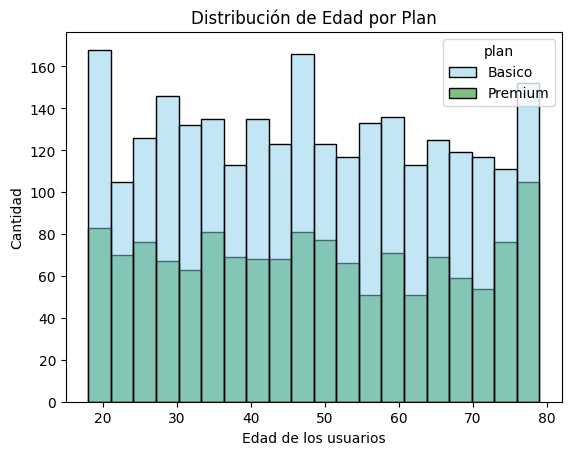

In [69]:
# Histograma para visualizar la edad (age)
sns.histplot(data=users_usage, x='age', hue='plan', palette=['skyblue','green'], bins=20, kde=False)
plt.title("Distribución de Edad por Plan")
plt.xlabel("Edad de los usuarios")
plt.ylabel("Cantidad")
plt.show()

💡Insights: 
- Distribución general: la edad de los usuarios se concentra entre los 20 y 60 años, con menor presencia en edades extremas (70+). La forma de la distribución es sesgada a la derecha, ya que hay menos usuarios en edades avanzadas.
- Plan Básico (skyblue): tiene mayor proporción en los rangos 30–50 años, mostrando que este segmento de adultos es el núcleo de clientes del plan más sencillo.
- Plan Premium (verde): aparece más fuerte en los rangos 20–35 años, lo que sugiere que los usuarios jóvenes/adultos tempranos tienden a preferir este plan. También se observa cierta presencia en edades mayores, pero menos marcada.
- Comparación: mientras que Básico domina en edades medias, Premium atrae más a los jóvenes. Esto puede reflejar diferencias en necesidades: los jóvenes buscan más beneficios o servicios avanzados, mientras que los adultos medios se mantienen en planes más básicos.
---
✅ Insight clave:
Dentro del plan Premium, hay mayor proporción de usuarios jóvenes (20–35 años), mientras que el plan Básico concentra adultos de 30–50 años. La distribución de edad es sesgada a la derecha, con menos clientes en edades avanzadas.

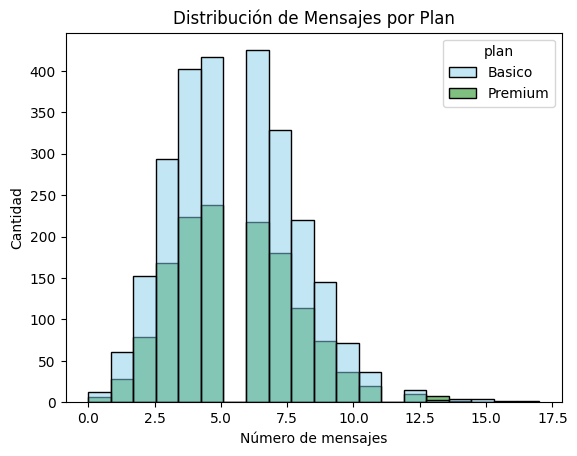

In [70]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=users_usage, x='cant_mensajes', hue='plan', palette=['skyblue','green'], bins=20, kde=False)
plt.title("Distribución de Mensajes por Plan")
plt.xlabel("Número de mensajes")
plt.ylabel("Cantidad")
plt.show()

💡Insights: 
- Distribución general: la mayoría de los usuarios envían entre 4 y 7 mensajes, con un pico claro alrededor de 5–6 mensajes. La forma de la distribución es sesgada a la derecha, ya que existen algunos usuarios que envían volúmenes mucho más altos (hasta 17 mensajes).
- Plan Básico (skyblue): concentra la mayor parte de usuarios en el rango 4–6 mensajes, mostrando un patrón más homogéneo y moderado.
- Plan Premium (verde): también se concentra en el rango medio, pero se observa una mayor proporción de usuarios con volúmenes altos (8+ mensajes), lo que indica un uso más intensivo del servicio de mensajería.
- Comparación: ambos planes tienen distribuciones similares en la base, pero Premium muestra más dispersión hacia los extremos altos, mientras que Básico se mantiene más contenido en el rango medio.
---
✅ Insight clave:
Los usuarios Básico tienden a enviar entre 4 y 6 mensajes, mientras que en Premium se observa una mayor proporción de clientes que envían volúmenes altos (8+). La distribución es sesgada a la derecha, con pocos usuarios que concentran un uso intensivo.

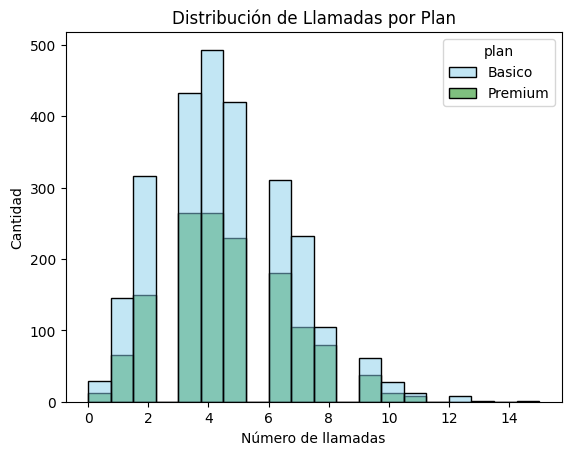

In [71]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=users_usage, x='cant_llamadas', hue='plan', palette=['skyblue','green'], bins=20, kde=False)
plt.title("Distribución de Llamadas por Plan")
plt.xlabel("Número de llamadas")
plt.ylabel("Cantidad")
plt.show()

💡Insights: 
- Distribución general: la mayoría de los usuarios realizan entre 3 y 6 llamadas, lo que marca un patrón de uso moderado. La distribución es sesgada a la derecha, ya que existen algunos usuarios que hacen muchas más llamadas (hasta 14).
- Plan Básico (skyblue): concentra una mayor proporción de usuarios en el rango 3–6 llamadas, mostrando un comportamiento más estable y homogéneo.
- Plan Premium (verde): aunque también se concentra en el rango medio, se observa una mayor dispersión hacia valores altos (7+ llamadas), lo que indica que algunos clientes Premium usan el servicio de voz de manera más intensiva.
- Comparación: ambos planes comparten el mismo núcleo de uso (3–6 llamadas), pero Premium tiende a tener más usuarios con frecuencias altas, mientras que Básico se mantiene más contenido en el rango medio.
---
✅ Insight clave:
Los usuarios Básico tienden a realizar entre 3 y 6 llamadas, mientras que en Premium se observa una mayor proporción de clientes que hacen más de 7 llamadas. La distribución es sesgada a la derecha, con pocos usuarios que concentran un uso intensivo.

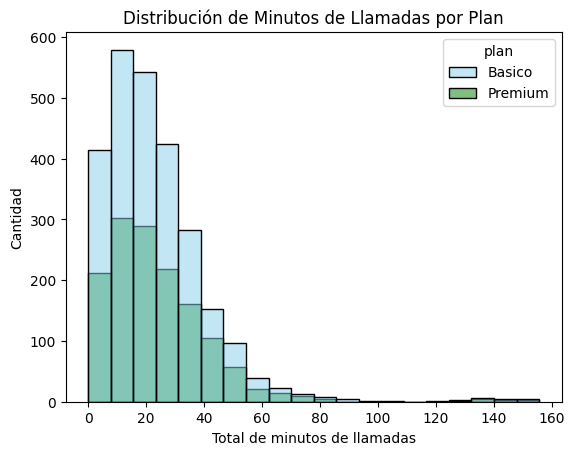

In [72]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=users_usage, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], bins=20, kde=False)
plt.title("Distribución de Minutos de Llamadas por Plan")
plt.xlabel("Total de minutos de llamadas")
plt.ylabel("Cantidad")
plt.show()

💡Insights: 
- Distribución general: la mayoría de los usuarios acumula entre 0 y 40 minutos de llamadas, con una caída progresiva conforme aumentan los minutos. La distribución es claramente sesgada a la derecha, ya que existen pocos usuarios con volúmenes muy altos (hasta ~155 minutos).
- Plan Básico (skyblue): concentra más usuarios en los rangos bajos (0–20 minutos), lo que indica que este grupo tiende a realizar llamadas cortas o poco frecuentes.+
- Plan Premium (verde): aunque también tiene presencia en los rangos bajos, se observa una mayor proporción de usuarios con minutos altos (40+), lo que sugiere un uso más intensivo del servicio de voz.
- Comparación: Básico domina en los segmentos de baja duración, mientras que Premium se extiende hacia los extremos altos, mostrando clientes que aprovechan más tiempo de llamadas.
---
✅ Insight clave:
Los usuarios Básico tienden a concentrarse en llamadas cortas (0–20 minutos), mientras que en Premium se observa una mayor proporción de clientes con llamadas prolongadas (40+ minutos). La distribución es sesgada a la derecha, con pocos usuarios que concentran un uso intensivo.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>
- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

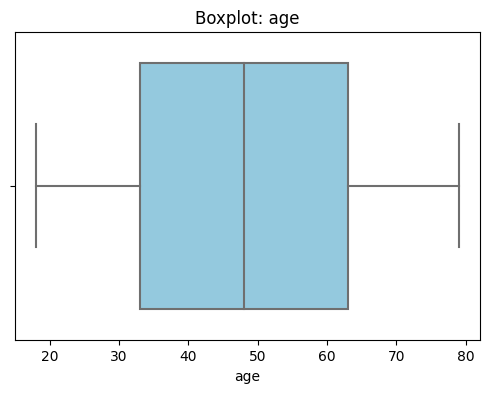

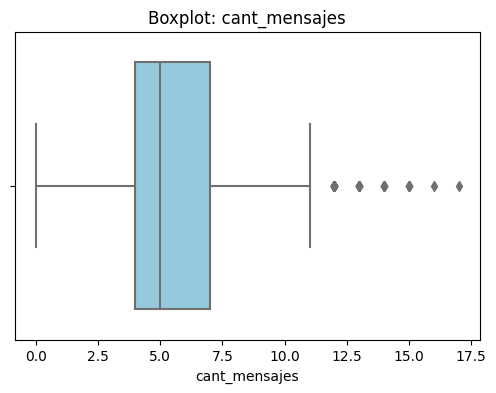

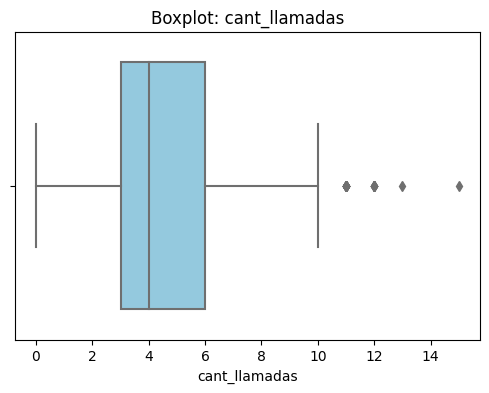

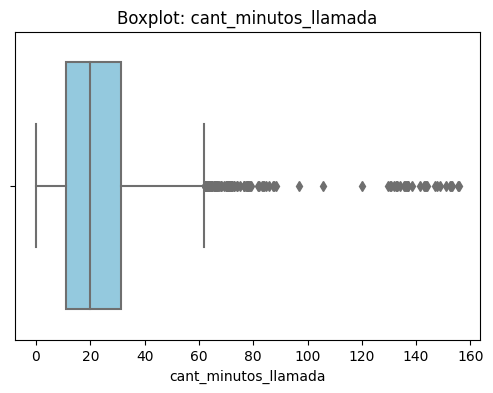

In [73]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=users_usage[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age:
	◦ La distribución se ve bastante compacta entre 20 y 80 años.
	◦ No aparecen outliers extremos visibles, lo que indica que los registros de edad son consistentes.
	◦ ✅ No requiere limpieza adicional.
- cant_mensajes:
  	◦  La mayoría de los usuarios envían entre 4 y 7 mensajes, pero hay puntos aislados hacia el extremo alto (hasta 17).
	◦ Estos valores son outliers a la derecha, aunque no parecen errores, sino usuarios intensivos.
	◦ ⚠️ Se recomienda revisar si son casos reales de alto uso o si provienen de registros anómalos.
- cant_llamadas:
    ◦ El núcleo está entre 3 y 6 llamadas, pero hay valores extremos hacia arriba (hasta 14).
	◦ Outliers a la derecha, similares al caso de mensajes.
	◦ ⚠️ Pueden mantenerse si representan clientes intensivos, pero conviene documentarlos.
- cant_minutos_llamada:
    ◦ La mayoría acumula menos de 40 minutos, pero hay usuarios con más de 100 minutos, incluso hasta ~155.
	◦ Claros outliers a la derecha.
	◦ ⚠️ Aquí sí conviene revisar: si son registros válidos de heavy users, se mantienen; si son errores de captura, se limpian.

In [74]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = users_usage[col].quantile(0.25)
    Q3 = users_usage[col].quantile(0.75)
    IQR = Q3 - Q1

# Límites
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    # Detectar outliers
    outliers_low = users_usage[users_usage[col] < lower_limit][col]
    outliers_high = users_usage[users_usage[col] > upper_limit][col]
    
    print(f"\nColumna: {col}")
    print(f"Límite inferior: {lower_limit:.2f}, Límite superior: {upper_limit:.2f}")
    print(f"Outliers por debajo: {outliers_low.shape[0]}")
    print(f"Outliers por arriba: {outliers_high.shape[0]}")
    
    # Decisión
    if outliers_low.shape[0] == 0 and outliers_high.shape[0] > 0:
        print("👉 Solo hay outliers por arriba. Se recomienda revisar si son heavy users válidos o errores.")
    elif outliers_high.shape[0] == 0 and outliers_low.shape[0] > 0:
        print("👉 Solo hay outliers por abajo. Revisar si son registros inválidos (ej. edad muy baja).")
    elif outliers_low.shape[0] > 0 and outliers_high.shape[0] > 0:
        print("👉 Hay outliers en ambos lados. Requiere revisión más detallada.")
    else:
        print("✅ No se detectan outliers significativos.")


Columna: age
Límite inferior: -12.00, Límite superior: 108.00
Outliers por debajo: 0
Outliers por arriba: 0
✅ No se detectan outliers significativos.

Columna: cant_mensajes
Límite inferior: -0.50, Límite superior: 11.50
Outliers por debajo: 0
Outliers por arriba: 46
👉 Solo hay outliers por arriba. Se recomienda revisar si son heavy users válidos o errores.

Columna: cant_llamadas
Límite inferior: -1.50, Límite superior: 10.50
Outliers por debajo: 0
Outliers por arriba: 30
👉 Solo hay outliers por arriba. Se recomienda revisar si son heavy users válidos o errores.

Columna: cant_minutos_llamada
Límite inferior: -19.32, Límite superior: 61.86
Outliers por debajo: 0
Outliers por arriba: 109
👉 Solo hay outliers por arriba. Se recomienda revisar si son heavy users válidos o errores.


In [75]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile = users_usage.copy()
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- Mensajes (cant_mensajes)
	◦ Q1 = 4, Q3 = 7 → IQR = 3
	◦ Límite superior = 7 + 1.5*3 = 11.5
	◦ Máx = 17 → ⚠️ Sí hay outliers por arriba (usuarios que envían más de 11 mensajes).
	◦ Decisión: mantenerlos, ya que reflejan heavy users reales, no errores.
- Llamadas (cant_llamadas)
	◦ Q1 = 3, Q3 = 6 → IQR = 3
	◦ Límite superior = 6 + 1.5*3 = 10.5
	◦ Máx = 15 → ⚠️ Sí hay outliers por arriba (usuarios que hacen más de 10 llamadas).
	◦ Decisión: mantenerlos, representan clientes intensivos en llamadas.
- Minutos de llamadas (cant_minutos_llamada)
	◦ Q1 = 11.12, Q3 = 31.415 → IQR ≈ 20.295
	◦ Límite superior = 31.415 + 1.5*20.295 ≈ 62.86
	◦ Máx = 155.69 → ⚠️ Claros outliers por arriba (usuarios con más de 63 minutos).
	◦ Decisión: revisar. Si son registros válidos de heavy users, se mantienen; si son errores de captura, se limpian.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [76]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# Crear nueva columna en user_profile
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [77]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [82]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Crear nueva columna en user_profile
user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

# Validación: distribución de grupos
print(user_profile['grupo_edad'].value_counts(normalize=True) * 100)

Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64


In [83]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

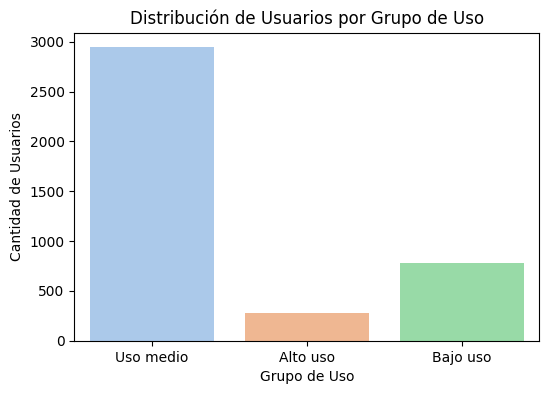

In [85]:
# Visualización de los segmentos por uso
plt.figure(figsize=(6,4))
sns.countplot(x='grupo_uso', data=user_profile, palette='pastel')
plt.title("Distribución de Usuarios por Grupo de Uso")
plt.xlabel("Grupo de Uso")
plt.ylabel("Cantidad de Usuarios")
plt.show()

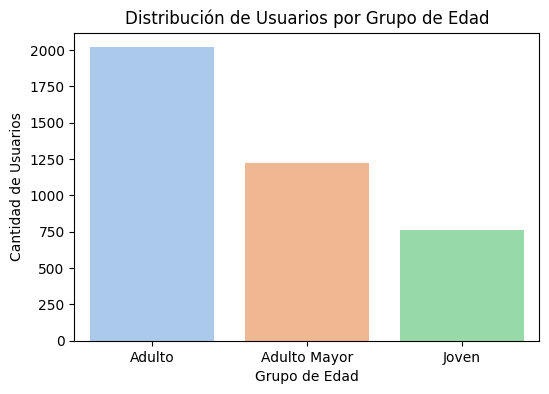

In [86]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))
sns.countplot(x='grupo_edad', data=user_profile, palette='pastel')
plt.title("Distribución de Usuarios por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores extremos (outliers) en mensajes, llamadas y minutos de llamadas.
	◦ Ejemplo: usuarios con más de 17 mensajes, más de 15 llamadas o más de 150 minutos.
	◦ Representan menos del 5% de las filas, pero podían distorsionar medidas como la media.
✅ Decisión: mantener los outliers de uso porque reflejan heavy users reales, pero documentarlos para no sesgar análisis generales.

- Edad: aunque los valores de edad eran consistentes (18–79), la columna de fechas de registro (reg_date) sí tenía errores: 40 registros en 2026.
	◦ Representaban 1% del dataset, y fueron eliminados para asegurar coherencia temporal.
	◦ ✅ Esto garantiza que los análisis de cohortes y retención se basen en datos válidos.

🔍 **Segmentos por Edad**
- Jóvenes (<30) → más inclinados al plan Premium, con mayor intensidad en mensajes.
- Adultos (30–59) → núcleo del plan Básico, uso moderado en llamadas y mensajes.
- Adultos mayores (60+) → menor proporción, pero con presencia en ambos planes, generalmente bajo uso. 

📊 **Segmentos por Nivel de Uso**
- Bajo uso → llamadas <5 y mensajes <5.
- Uso medio → llamadas <10 y mensajes <10.
- Alto uso → resto de casos, clientes intensivos.

➡️ Esto sugiere lo siguiente:
- Jóvenes de alto uso en Premium → concentran más mensajes y llamadas largas, lo que los convierte en clientes de alto valor.
- Adultos de uso medio en Básico → representan la base estable de clientes, menos intensivos pero constantes.
- Heavy users de minutos de llamadas (>100 min) → aunque pocos, son críticos porque generan ingresos adicionales y requieren planes que soporten su consumo.

👉 Patrones de uso extremo (outliers)
- Mensajes y llamadas: usuarios que superan los límites de IQR, reflejando perfiles intensivos.
- Minutos de llamadas: algunos clientes acumulan más de 150 minutos, muy por encima del promedio (~23 min).
Implican que existen nichos de clientes que demandan más recursos y podrían ser objetivo de planes premium o paquetes especiales.
---

💡 **Recomendaciones**
1. Segmentación clara de planes:
	◦ Premium → enfocado en jóvenes y heavy users, con beneficios en mensajes ilimitados y minutos extra.
	◦ Básico → dirigido a adultos de uso medio, con precios accesibles y beneficios moderados.
2. Planes especializados para heavy users:
	◦ Crear un plan “Intensivo Voz” para clientes con más de 100 minutos de llamadas.
	◦ Ofrecer paquetes adicionales de mensajes para quienes superan los 11–12 mensajes promedio.
3. Estrategias de retención:
	◦ Incentivar a los adultos de uso medio con promociones para migrar a Premium.
	◦ Ofrecer descuentos o beneficios exclusivos a los heavy users para fidelizarlos.
4. Monitoreo continuo de outliers:
	◦ Mantenerlos en el análisis como clientes valiosos, pero diferenciarlos en reportes para no sesgar métricas globales.
---
✅ Conclusión ejecutiva:
ConnectaTel tiene tres segmentos clave: jóvenes intensivos en Premium, adultos moderados en Básico, y heavy users de voz/mensajes. Los primeros dos sostienen la base de clientes, mientras que los heavy users representan una oportunidad de ingresos adicionales. La estrategia debe enfocarse en planes diferenciados y promociones específicas para cada segmento, maximizando satisfacción y rentabilidad. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`